Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

In [ ]:
"""
A Decision Tree is a supervised machine learning algorithm used for both
classification and regression problems. It works by splitting the data into
smaller groups based on feature values and making decisions in a tree-like structure.

Structure of a Decision Tree:

1. Root Node
   The top-most node that represents the entire dataset.

2. Internal Nodes
   Nodes where decisions or conditions are applied.

3. Leaf Nodes
   Final nodes that contain the prediction or output.

Real-Life Example:

Suppose a bank wants to predict whether a customer will subscribe to a deposit scheme.

Root Node:
    Does the customer have a housing loan?

Internal Node:
    Is the account balance greater than 1000?

Leaf Node:
    Yes → Likely to subscribe.
    No → Not likely to subscribe.

Decision Trees are easy to understand and visualize, making them useful for business decision-making.
"""

Q2. Differentiate between Gini Impurity and Entropy.
Which one is used by default in Scikit-learn and why?

In [ ]:
"""
Gini Impurity and Entropy are measures used to determine the quality of a split in a Decision Tree.

Gini Impurity:
- Measures the probability of incorrect classification.
- Computationally faster.
- Lower value indicates better purity.

Entropy:
- Measures randomness or uncertainty in the data.
- Uses logarithmic calculations.
- Lower value indicates less uncertainty.

Difference:

Gini Impurity:
- Faster computation
- Simpler calculation

Entropy:
- Slightly more computationally expensive
- Based on information gain

Scikit-learn uses Gini Impurity as the default criterion because it is computationally efficient and generally provides similar performance to Entropy.
"""

Q3. What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?

In [ ]:
"""
Overfitting occurs when a Decision Tree learns the training data too well,
including noise and unnecessary details.

As a result:
- Training accuracy becomes very high.
- Testing accuracy becomes significantly lower.

Overfitting can be detected by comparing training and testing accuracy.

Example:

Training Accuracy = 99%
Testing Accuracy = 80%

This large difference indicates that the model has memorized the training data and does not generalize well to new data.

Therefore, a good model should have training and testing accuracies that are reasonably close to each other.
"""

Q4. Explain Pruning in Decision Trees.
What is the difference between Pre-pruning and Post-pruning?

In [ ]:
"""
Pruning is a technique used to reduce the size of a Decision Tree and prevent overfitting.

Pre-Pruning:
- Stops tree growth before the tree becomes too complex.
- Uses parameters such as:
  - max_depth
  - min_samples_split
  - min_samples_leaf

Post-Pruning:
- First grows the complete tree.
- Then removes unnecessary branches.

Difference:

Pre-Pruning:
- Controls complexity during training.
- Faster training process.

Post-Pruning:
- Removes branches after training.
- Often produces a more optimized tree.

Pruning improves model generalization and reduces overfitting.
"""

Q5. What is Feature Importance?
How can it help businesses in decision-making?

In [ ]:
"""
Feature Importance measures the contribution of each feature in making predictions.

Features with higher importance values have a greater influence on the model's decisions.

Business Benefits:

1. Identifies the most influential factors.
2. Helps reduce unnecessary variables.
3. Improves decision-making.
4. Makes the model easier to interpret.

For a bank marketing campaign, feature importance can help identify which customer characteristics most strongly influence deposit subscription decisions.
"""

Q6. Data Understanding

Load the dataset

Display first 5 rows

Check:

Shape

Data types

Column names

Interpret:

What types of variables are present?

In [1]:
import pandas as pd

df = pd.read_csv("C:\\Users\\CC\\Downloads\\bank.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
df.shape

(11162, 17)

In [4]:
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
deposit        str
dtype: object

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')

In [ ]:
"""
The dataset contains both numerical and categorical variables.

The target variable is 'deposit', which indicates whether
a customer subscribed to a term deposit or not.

Since the target variable contains two classes (yes/no),
this is a binary classification problem.
"""

Q7. Data Cleaning

Check for missing values

Handle missing values (if any)

Check for duplicates

Interpret:

Is the dataset clean? What issues did you find?

In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [ ]:
"""
No missing values were found in the dataset.

No duplicate records were detected.

Therefore, the dataset is clean and does not require
additional data cleaning before preprocessing.
"""

Q8. Data Preprocessing

Convert categorical variables into numerical

Mention which encoding method you used.

Interpret:
Why is encoding necessary for Decision Trees?

In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = df.select_dtypes(
    include=['object', 'string']
).columns

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

In [ ]:
"""
Label Encoding was used to convert categorical variables
into numerical format.

Machine learning algorithms require numerical input,
therefore categorical values such as job, marital status,
housing loan status, and deposit must be converted into numbers.

Encoding makes the dataset suitable for Decision Tree training.
"""

Q9. Feature Selection & Splitting

Separate:

Features (X)

Target (y)

Perform train-test split (80-20)

Interpret:

Why is train-test split important?

In [11]:
X = df.drop("deposit", axis=1)

y = df["deposit"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
"""
The dataset was divided into training and testing datasets.

80% of the data was used for training the model.

20% of the data was reserved for testing.

Train-test split is important because it allows us
to evaluate how well the model performs on unseen data.
"""

Q10. Model Building

Train a Decision Tree Classifier

Use:

criterion='gini'

max_depth=5

Interpret:

What does max_depth control?

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

In [ ]:
"""
The model was trained using Gini Impurity as the splitting criterion.

max_depth = 5 limits the maximum depth of the tree.

This helps prevent the model from becoming overly complex
and reduces the risk of overfitting.
"""

Q11. Model Evaluation 

Perform:

Accuracy score

Confusion Matrix

Classification Report

Interpret (MUST):

Is the model performing well?

Explain Precision & Recall

Any class imbalance issue?

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8051948051948052


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[867 299]
 [136 931]]


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



In [ ]:
"""
The model achieved an accuracy of approximately 81%.

Precision indicates how many positive predictions were correct.

Recall indicates how many actual positive cases were correctly identified.

The model performs reasonably well on both classes.

The dataset does not show severe class imbalance because
both classes have a relatively similar number of observations.
"""

Q12. Overfitting Check

Calculate:

Training accuracy

Testing accuracy

Interpret:

Is the model overfitting or underfitting?

In [17]:
train_accuracy = dt_model.score(X_train, y_train)

test_accuracy = dt_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8149848807257252
Testing Accuracy: 0.8051948051948052


In [ ]:
"""
Training accuracy and testing accuracy are very close.

Training Accuracy = 81.50%
Testing Accuracy = 80.52%

Since the difference is very small,
the model is neither overfitting nor underfitting.

The model generalizes well to unseen data.
"""

Q13. Pruning Experiment

Train another model with:

max_depth=3

min_samples_split=20

Interpret:

Compare performance with previous model

Which one is better and why?

In [18]:
pruned_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

pruned_model.fit(X_train, y_train)

pruned_pred = pruned_model.predict(X_test)

In [19]:
train_acc_pruned = pruned_model.score(X_train, y_train)

test_acc_pruned = pruned_model.score(X_test, y_test)

print(train_acc_pruned)
print(test_acc_pruned)

0.7778026654720573
0.7653381101656964


In [ ]:
"""
The pruned model is simpler and less complex.

However, its testing accuracy decreased from 80.52% to 76.53%.

Therefore, the original model with max_depth=5 performs better.

The original model achieves higher predictive accuracy
while still avoiding overfitting.
"""

Q14. Feature Importance

Extract top 5 important features

Plot feature importance graph

Interpret:

Which features influence prediction the most?

In [20]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head()

,Feature,Importance
11,duration,0.595239
8,contact,0.121729
13,pdays,0.084299
6,housing,0.067469
10,month,0.054023


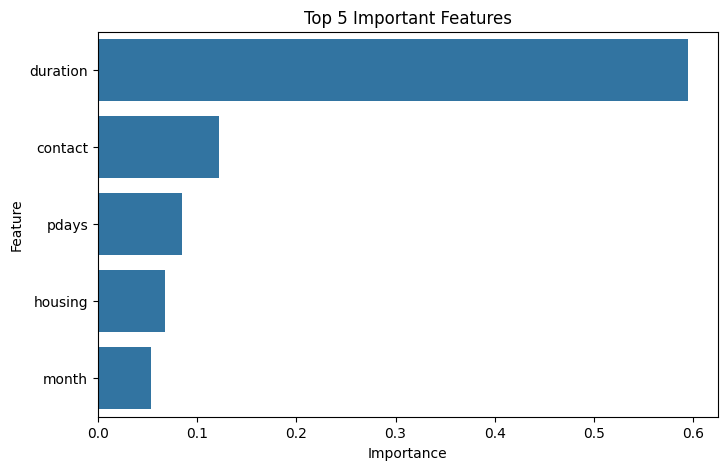

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

top5 = feature_importance.head(5)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top5
)

plt.title("Top 5 Important Features")

plt.show()

In [ ]:
"""
Duration is the most influential feature in predicting
whether a customer will subscribe to a term deposit.

Contact type, previous contact days, housing loan status,
and month also contribute significantly to prediction.

These features have the strongest impact on customer decisions.
"""

Q15. Business Insights 

Based on your model:

Answer:

Which type of customers are more likely to say “yes”?

What strategy should a bank use?

In [ ]:
"""
Based on the model results, customers with longer call durations,
favorable contact history, and suitable financial profiles are more
likely to subscribe to a term deposit.

Customers who have been contacted successfully in the past and
show positive engagement during calls have a higher probability
of saying 'yes'.

Recommended Strategy:

1. Focus marketing efforts on customers with positive contact history.
2. Improve call quality and customer engagement.
3. Target customers during effective campaign months.
4. Prioritize customers identified by the model as high-probability prospects.
5. Use predictive analytics to optimize future marketing campaigns.

These strategies can improve conversion rates and increase
term deposit subscriptions.
"""